In [1]:
!pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.3 MB/s eta 0:00:00


In [ ]:
import os
import sys
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams

import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

main_path = '/content/gdrive/My Drive/0 - FORECASTING/02 - sarimax/'
file_path = os.path.join(main_path, 'all_data.xlsx')

main_out = sys.stdout

output_name = 'output_file.txt'
output_file = os.path.join(main_path, output_name)
sys.stdout = open(output_file, 'w')

print('=========== OUTPUT FILE ===========\n\n')



Mounted at /content/gdrive


In [2]:
columns = ['Date', 'POC', 'SST', 'CHL', 'SAL', 'NINO3', 'eioDMI']
df = pd.read_excel("/content/gdrive/My Drive/0 - FORECASTING/02 - sarimax/all_data.xlsx", usecols=columns)

#string to date format
df['Date'] = pd.to_datetime(df['Date'],infer_datetime_format=True)
df = df.set_index(['Date'])
df.head(5)


NameError: name 'pd' is not defined

In [ ]:
df.tail(5)

,POC,SST,CHL,SAL,NINO3,eioDMI
Date,,,,,,
2022-10-31,108.437744,29.628010,0.682454,NaN,-1.05,0.342
2022-11-30,124.169079,29.831083,1.220436,NaN,-0.72,0.134
2022-12-31,130.848919,29.671063,1.104675,NaN,-0.84,0.091
2023-01-31,118.428019,28.842859,0.727072,NaN,-0.64,-0.193
2023-02-28,124.536958,28.516984,0.851302,NaN,-0.47,-0.213


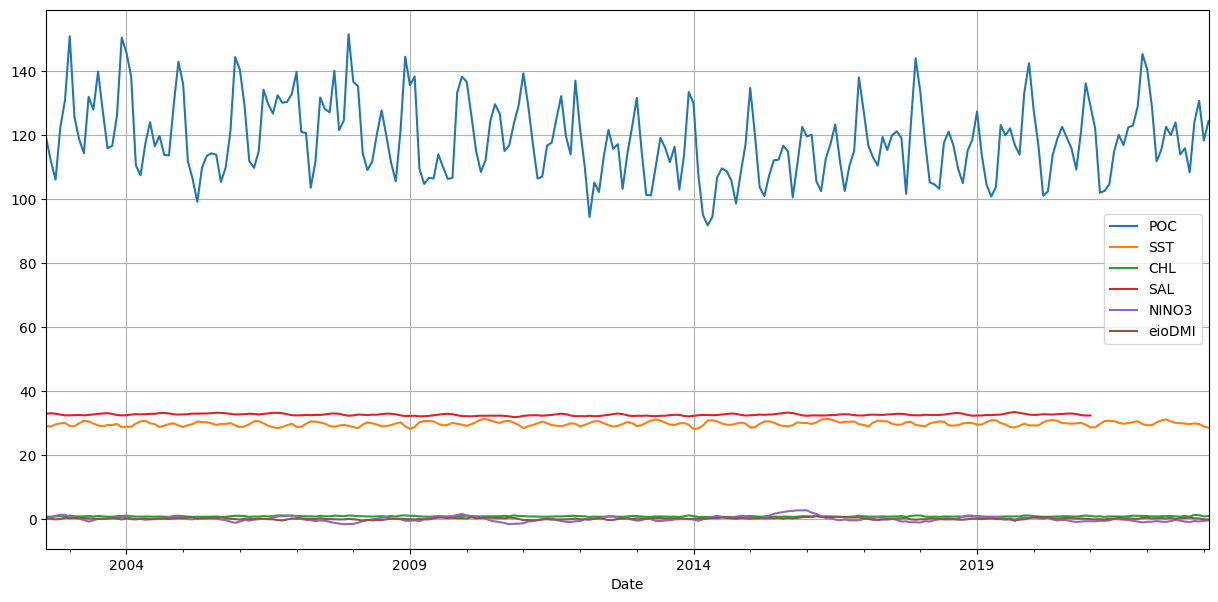

In [ ]:
from matplotlib.dates import MonthLocator, DateFormatter, DayLocator
from matplotlib.ticker import NullFormatter

X = df

X.plot(figsize=(15, 7))
plt.grid()

plt.show()

In [ ]:
X.head()

,POC,SST,CHL,SAL,NINO3,eioDMI
Date,,,,,,
2002-08-31,119.282833,29.038318,0.673731,32.88780,0.34,0.075
2002-09-30,112.031085,28.852276,0.635578,33.02058,0.51,0.007
2002-10-31,106.160381,29.513764,0.721020,32.89138,0.93,-0.186
2002-11-30,122.402259,29.854891,0.800629,32.60980,1.24,-0.083
2002-12-31,130.961725,29.995386,0.780790,32.37581,1.25,0.305


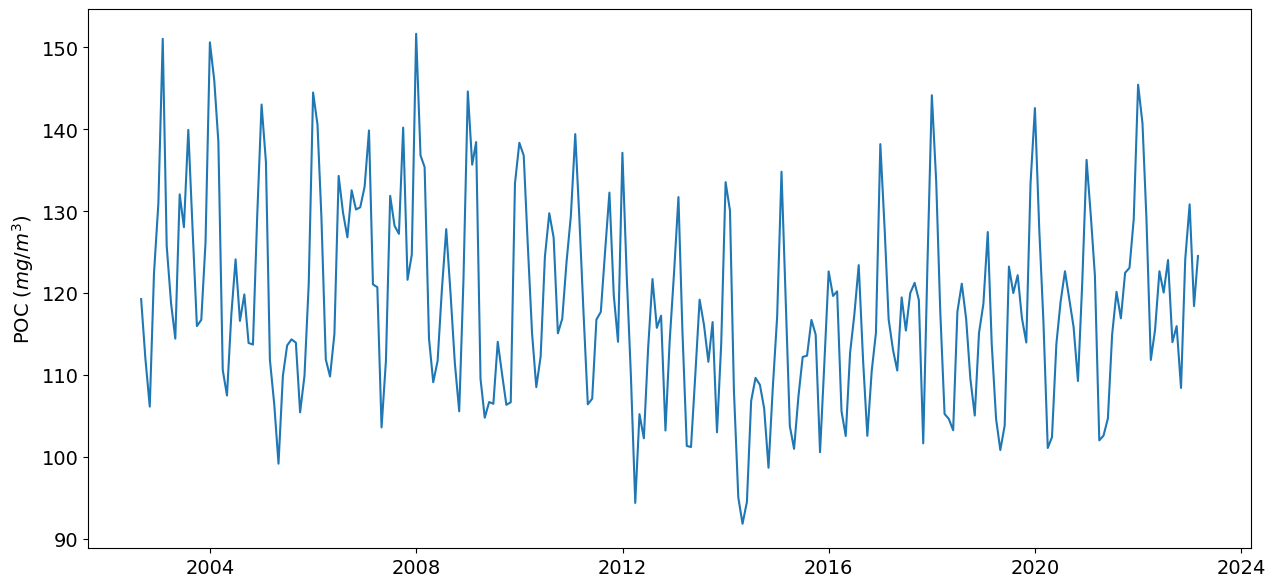

In [ ]:
plt.figure(figsize=(15, 7))
#plt.title("Multi-annual variability of POC", fontsize=16)
#plt.xlabel('Time', fontsize=14)
plt.ylabel('POC ($mg/m^3$)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.plot(df['POC'])

savedir = os.path.join(main_path, 'Figure 01 - POC.pdf')
plt.savefig(savedir)

plt.show()

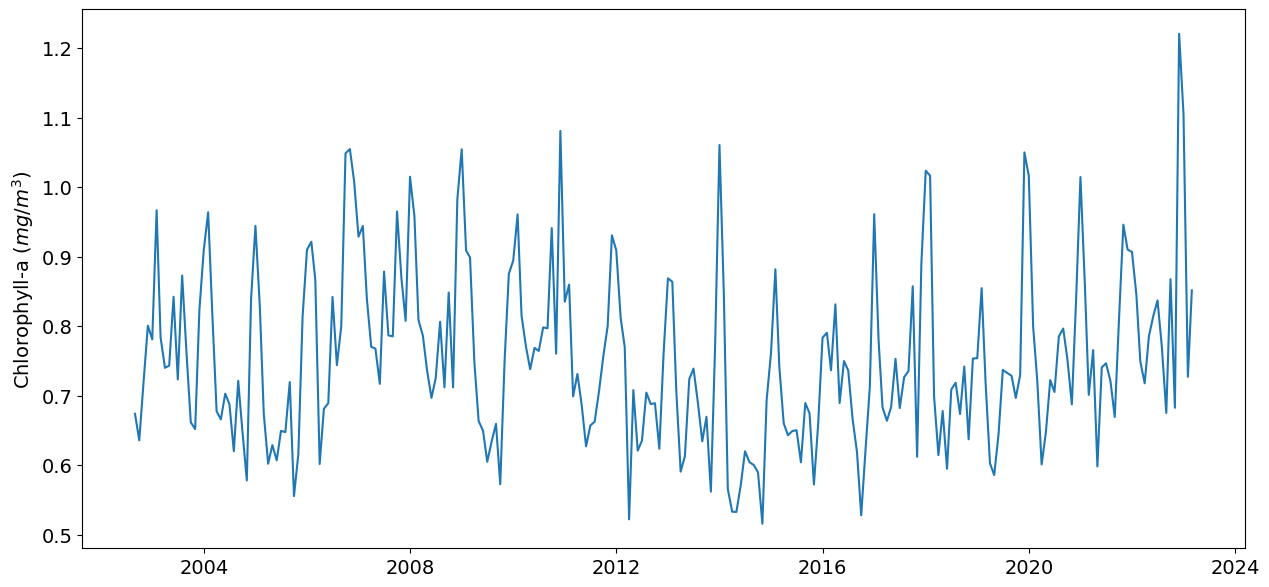

In [ ]:
plt.figure(figsize=(15, 7))
#plt.title("Multi-annual variability of Chlorophyll-a", fontsize=16)
#plt.xlabel('Time', fontsize=14)
plt.ylabel('Chlorophyll-a ($mg/m^3$)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.plot(df['CHL'])

savedir = os.path.join(main_path, 'Figure 02 - CHL.pdf')
plt.savefig(savedir)

plt.show()

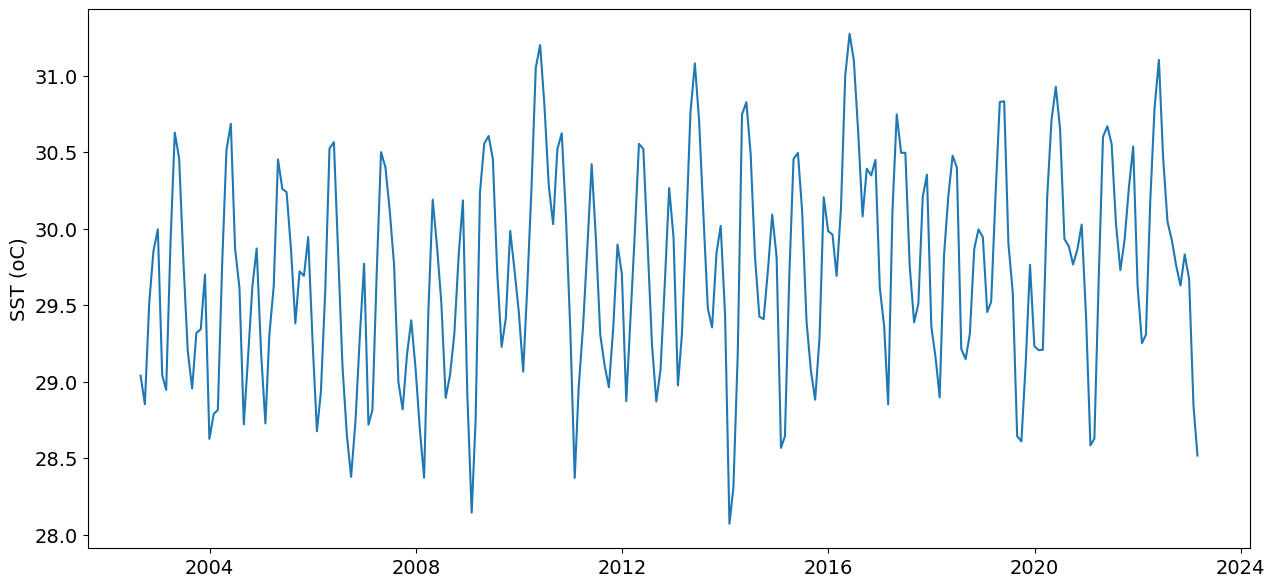

In [ ]:
plt.figure(figsize=(15, 7))
#plt.title("Multi-annual variability of SST", fontsize=16)
#plt.xlabel('Time', fontsize=14)
plt.ylabel('SST (oC)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.plot(df['SST'])

savedir = os.path.join(main_path, 'Figure 03 - SST.pdf')
plt.savefig(savedir)

plt.show()

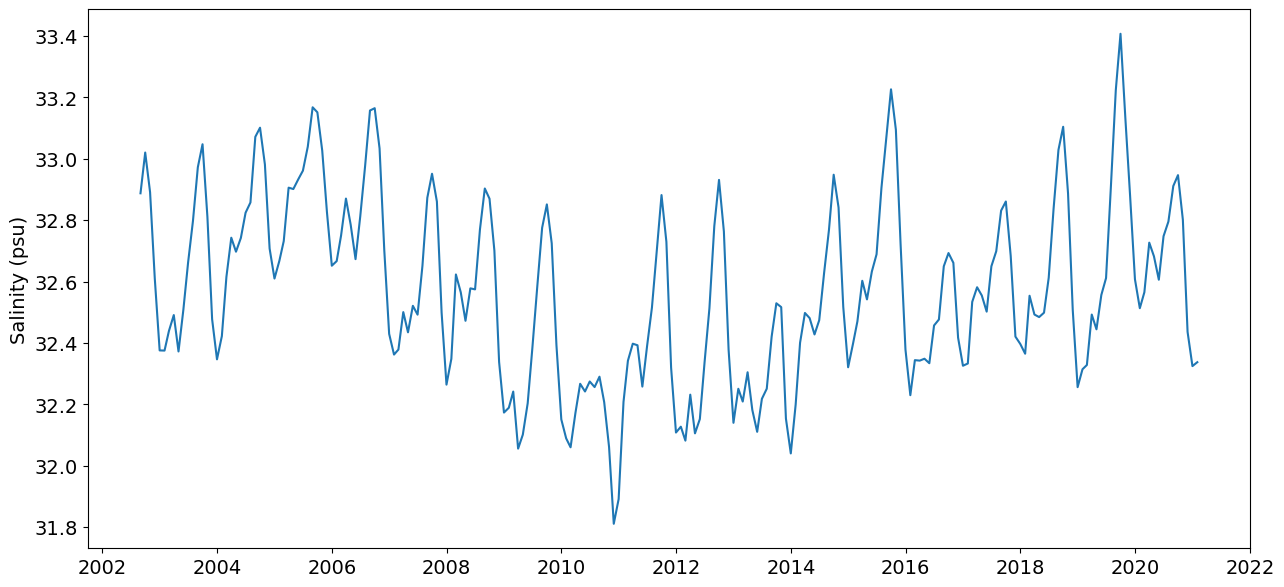

In [ ]:
plt.figure(figsize=(15, 7))
#plt.title("Multi-annual variability of salinity", fontsize=16)
#plt.xlabel('Time', fontsize=14)
plt.ylabel('Salinity (psu)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.plot(df['SAL'])

savedir = os.path.join(main_path, 'Figure 04 - Salinity.pdf')
plt.savefig(savedir)

plt.show()

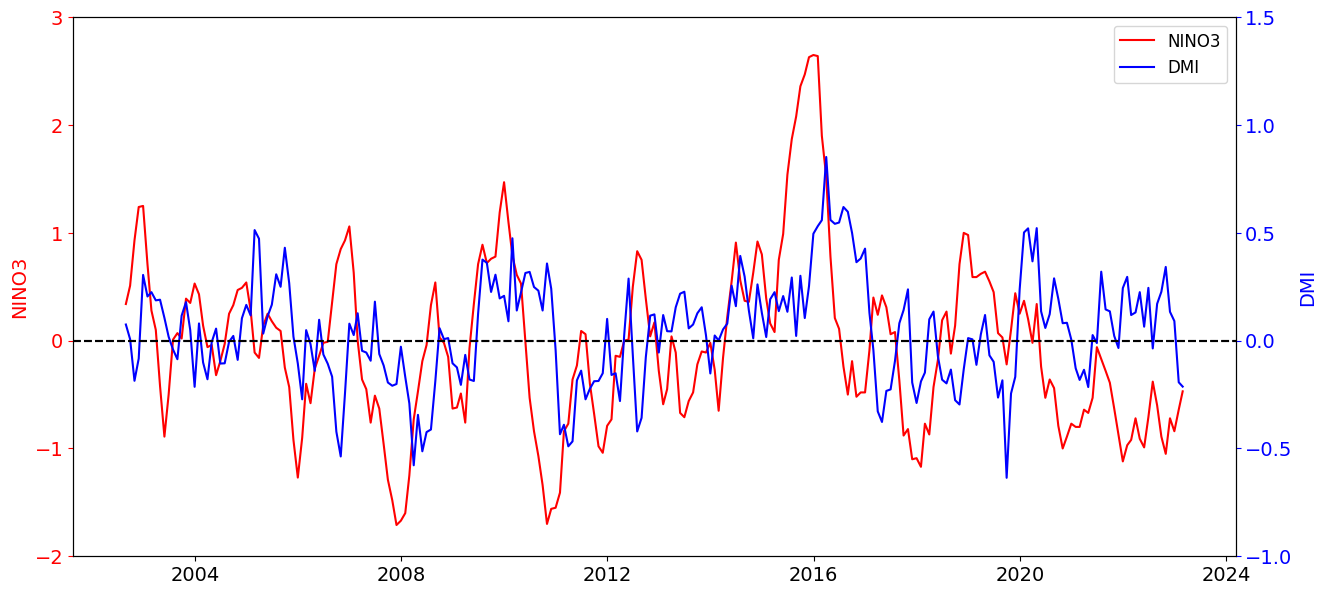

In [ ]:
# Create the figure and the first y-axis
fig, ax1 = plt.subplots(figsize=(15,7))

# Plot the first dataset on the first y-axis
ax1.plot(df['NINO3'], 'r-', label='NINO3')
#ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('NINO3', color='r', fontsize=14)
ax1.tick_params('y', colors='r', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

# Create the second y-axis
ax2 = ax1.twinx()

# Plot the second dataset on the second y-axis
ax2.plot(df['eioDMI'], 'b-', label='DMI')
ax2.set_ylabel('DMI', color='b', fontsize=14)
ax2.tick_params('y', colors='b', labelsize=14)

# Set the same major unit for both y-axes
unit1=1
unit2=0.5
ax1.set_yticks(np.arange(-2, 3.5, unit1))
ax2.set_yticks(np.arange(-1, 2, unit2))

# Add the horizontal line
ax1.axhline(0, color='k', linestyle='--')
ax2.axhline(0, color='k', linestyle='--')

# Display the legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=12)

# Save the plot
savedir = os.path.join(main_path, 'Figure 05 - NINO3 & DMI.pdf')
plt.savefig(savedir)

# Show the plot
plt.show()

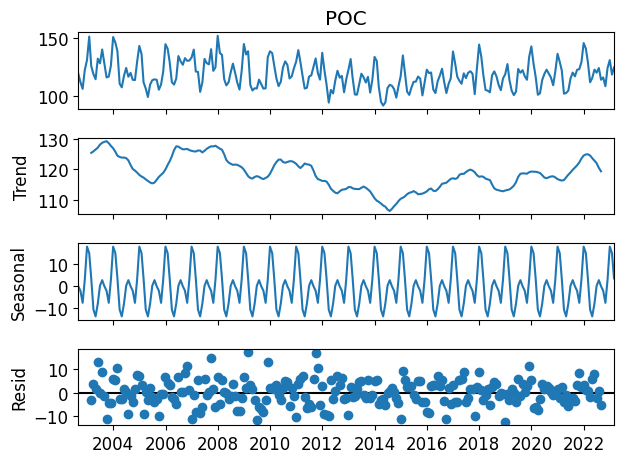

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Increase font size globally
plt.rcParams.update({'font.size': 12})

decompose_data = seasonal_decompose(X['POC'], model="additive")
decompose_data.plot()

savedir = os.path.join(main_path, 'Figure 06 - komponen_time_series.pdf')
plt.savefig(savedir)

plt.show()

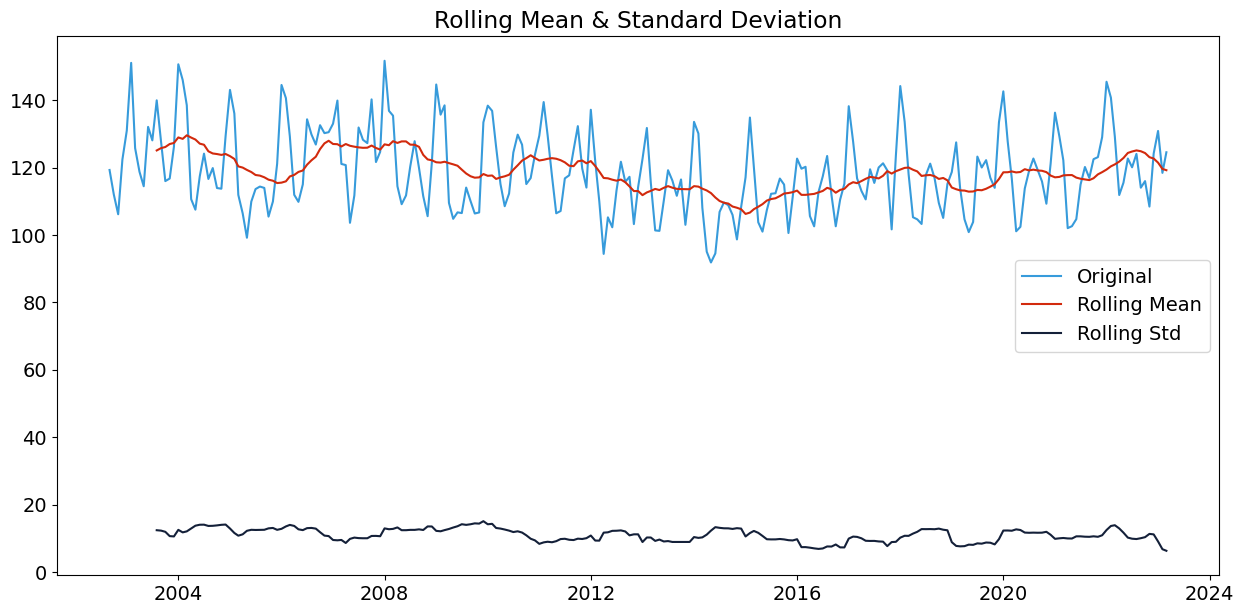

In [ ]:
#Determine rolling statistics
df["rolling_avg"] = df["POC"].rolling(window=12).mean() #window size 12 denotes 12 months, giving rolling mean at yearly level
df["rolling_std"] = df["POC"].rolling(window=12).std()

# Increase font size globally
plt.rcParams.update({'font.size': 14})

#Plot rolling statistics
plt.figure(figsize=(15,7))
plt.plot(df["POC"], color='#379BDB', label='Original')
plt.plot(df["rolling_avg"], color='#D22A0D', label='Rolling Mean')
plt.plot(df["rolling_std"], color='#142039', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')

#save the plot
savedir = os.path.join(main_path, 'Figure 07 - rolling mean & STDev.pdf')
plt.savefig(savedir)

plt.show(block=False)

In [ ]:
#Augmented Dickey–Fuller test:
print('Results of Dickey Fuller Test:')
dftest = adfuller(df['POC'], autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value

print(dfoutput)

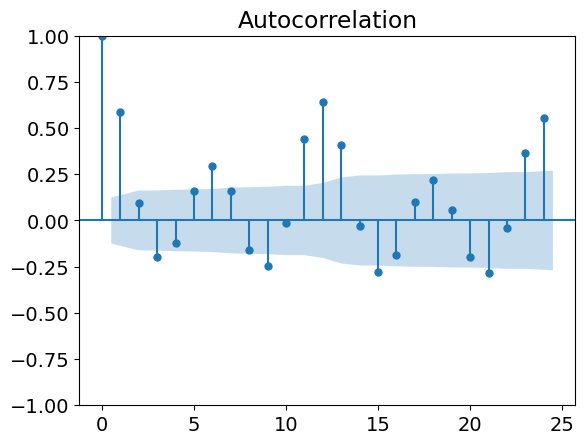

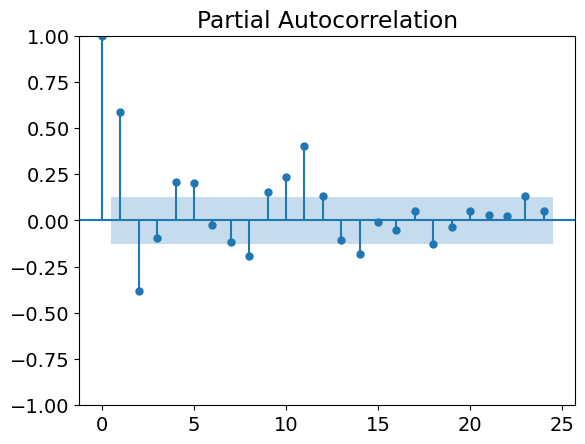

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Increase font size globally
plt.rcParams.update({'font.size': 14})

fig = sm.graphics.tsa.plot_acf(df["POC"])

savedir = os.path.join(main_path, 'Figure 08a_ACF-monthly m60.pdf')
plt.savefig(savedir)

fig = sm.graphics.tsa.plot_pacf(df["POC"])

savedir = os.path.join(main_path, 'Figure 08b_PACF-monthly m60.pdf')
plt.savefig(savedir)

plt.show()

In [ ]:
#Standard ARIMA Model
ARIMA_model = pm.auto_arima(df['POC'],
                      start_p=1,
                      start_q=1,
                      test='adf', # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                      d=1,# let model determine 'd'
                      seasonal=False, # No Seasonality for standard ARIMA
                      trace=False, #logs
                      error_action='warn', #shows errors ('ignore' silences these)
                      suppress_warnings=True,
                      stepwise=True)
print(ARIMA_model.summary())

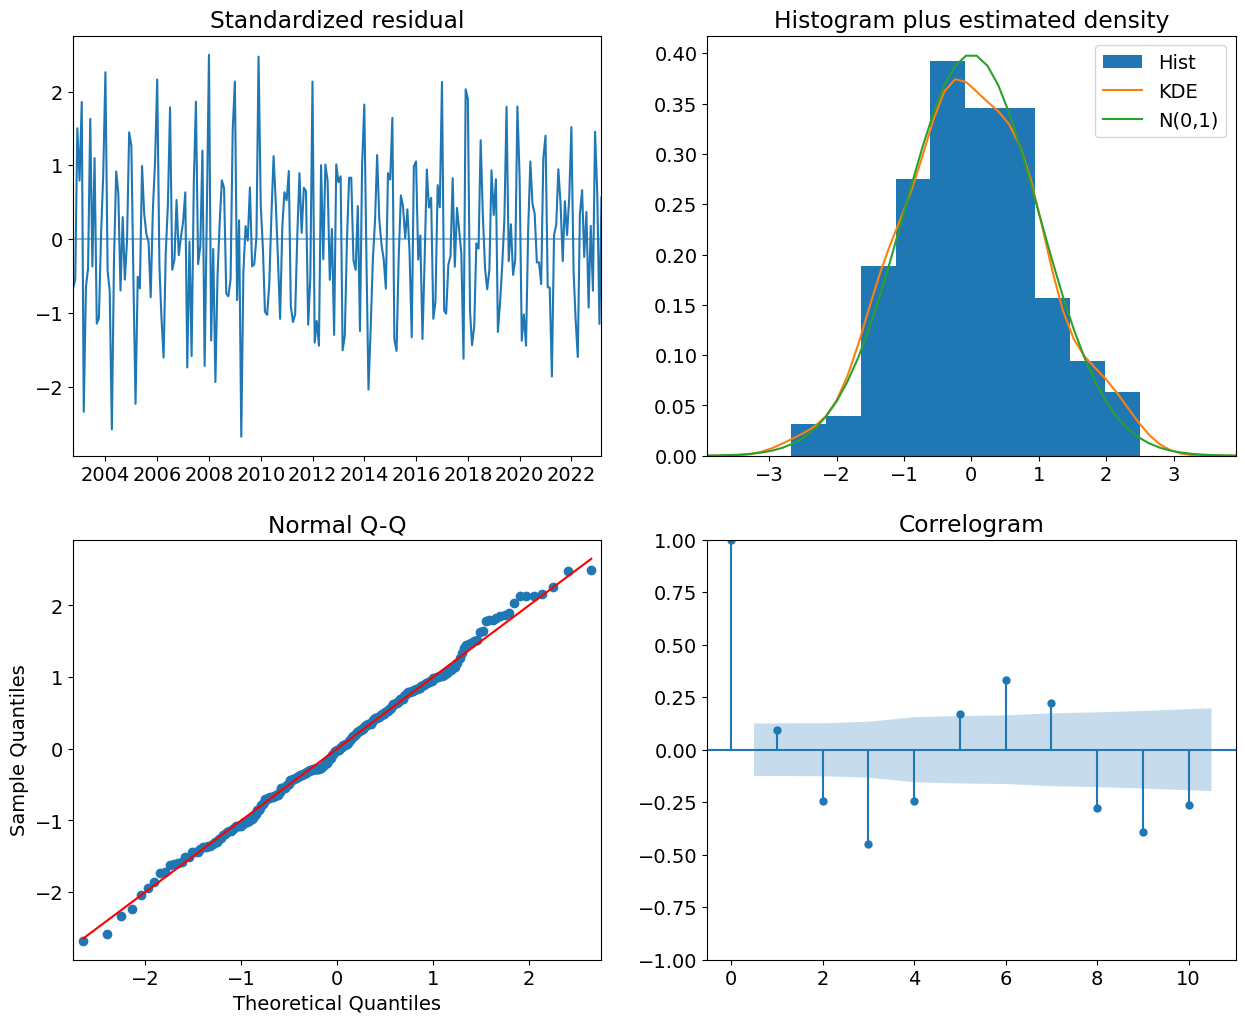

In [ ]:
# Increase font size globally
plt.rcParams.update({'font.size': 14})

#plot diagnostics
ARIMA_model.plot_diagnostics(figsize=(15,12))
savedir = os.path.join(main_path, 'Figure 09_ARIMA_model.plot_diagnostics I.pdf')
plt.savefig(savedir)
plt.show()

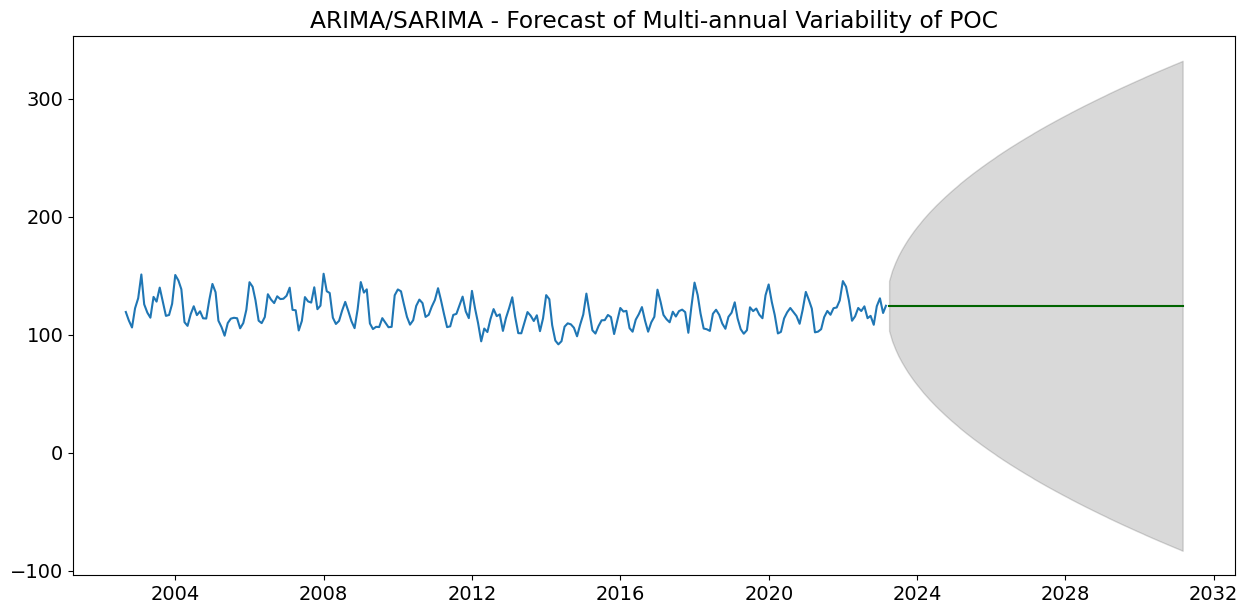

In [ ]:
def forecast(ARIMA_model, periods=96):
    # Forecast
    n_periods = periods
    fitted, confint = ARIMA_model.predict(n_periods=n_periods, return_conf_int=True)
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='M')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(df["POC"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                    lower_series,
                    upper_series,
                    color='k', alpha=.15)

    plt.title("ARIMA/SARIMA - Forecast of Multi-annual Variability of POC")
    plt.show()

forecast(ARIMA_model)

In [ ]:
# Seasonal - fit stepwise auto-ARIMA
SARIMA_model = pm.auto_arima(df["POC"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3,
                         m=60, #12 is the frequncy of the cycle; 60 is multi-annual for 5-years cycle
                         start_P=0,
                         seasonal=True, #set to seasonal
                         d=1,
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

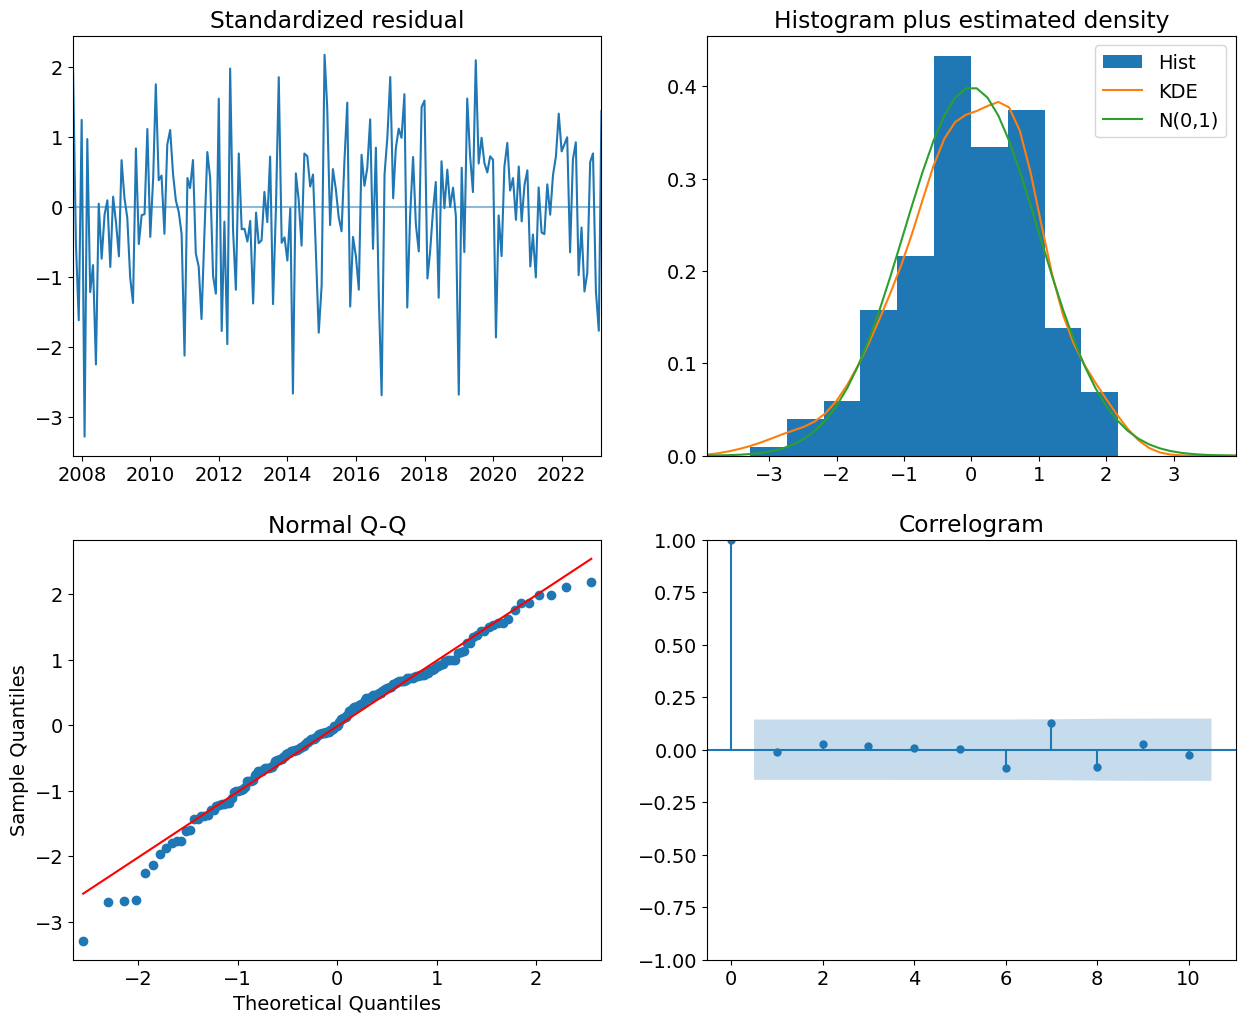

In [ ]:
# Increase font size globally
plt.rcParams.update({'font.size': 14})

#plot diagnostics
SARIMA_model.plot_diagnostics(figsize=(15,12))
savedir = os.path.join(main_path, 'Figure 10_SARIMA_model.plot_diagnostics II.pdf')
plt.savefig(savedir)
plt.show()

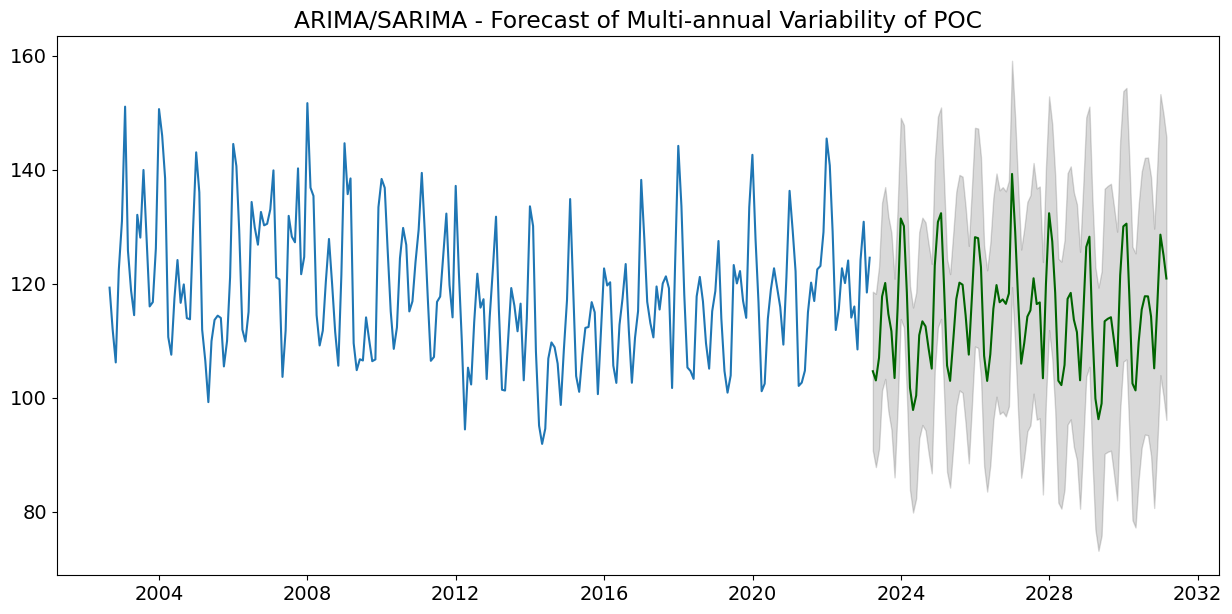

<Figure size 640x480 with 0 Axes>

In [ ]:
# Increase font size globally
plt.rcParams.update({'font.size': 14})

# Plot forecast
forecast(SARIMA_model)
savedir = os.path.join(main_path, 'Figure 11_forecast SARIMA.pdf')
plt.savefig(savedir)
plt.show()

In [ ]:
model=sm.tsa.statespace.SARIMAX(X['POC'],order=(1, 1, 2),seasonal_order=(2,1,0,60))
#m=60 if multi annual 5 years
results=model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


In [ ]:
print(results.summary(), end='\n\n')

In [ ]:
# Define the exogenous variables
exog = df[['SST', 'CHL', 'SAL', 'NINO3', 'eioDMI']]

# SARIMAX Model
SARIMAX_model = pm.auto_arima(df[['POC']], exogenous=[exog],
                           start_p=1, start_q=1,
                           test='adf',
                           max_p=3, max_q=3, m=60,
                           start_P=0, seasonal=True,
                           d=1, D=1,
                           trace=False,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

SARIMAX_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  247
Model:             SARIMAX(1, 1, 2)x(2, 1, [], 60)   Log Likelihood                -645.493
Date:                             Tue, 17 Oct 2023   AIC                           1302.986
Time:                                     19:12:12   BIC                           1322.340
Sample:                                 08-31-2002   HQIC                          1310.829
                                      - 02-28-2023                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7513      0.146      5.160      0.000       0.466       1.037
ma.L1         -1.3183      0.181     -7.293      0.000      -1.673      -0.964
ma.L2          0.3446      0.159      2.162      0.031       0.032       0.657
ar.S.L60      -0.6886      0.100     -6.889      0.000      -0.885      -0.493
ar.S.L120     -0.3139      0.119     -2.633      0.008      -0.548      -0.080
sigma2        50.6821      6.538      7.752      0.000      37.867      63.497
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 5.96
Prob(Q):                              0.87   Prob(JB):                         0.05
Heteroskedasticity (H):               0.70   Skew:                            -0.42
Prob(H) (two-sided):                  0.16   Kurtosis:                         3.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
print(SARIMAX_model.summary())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

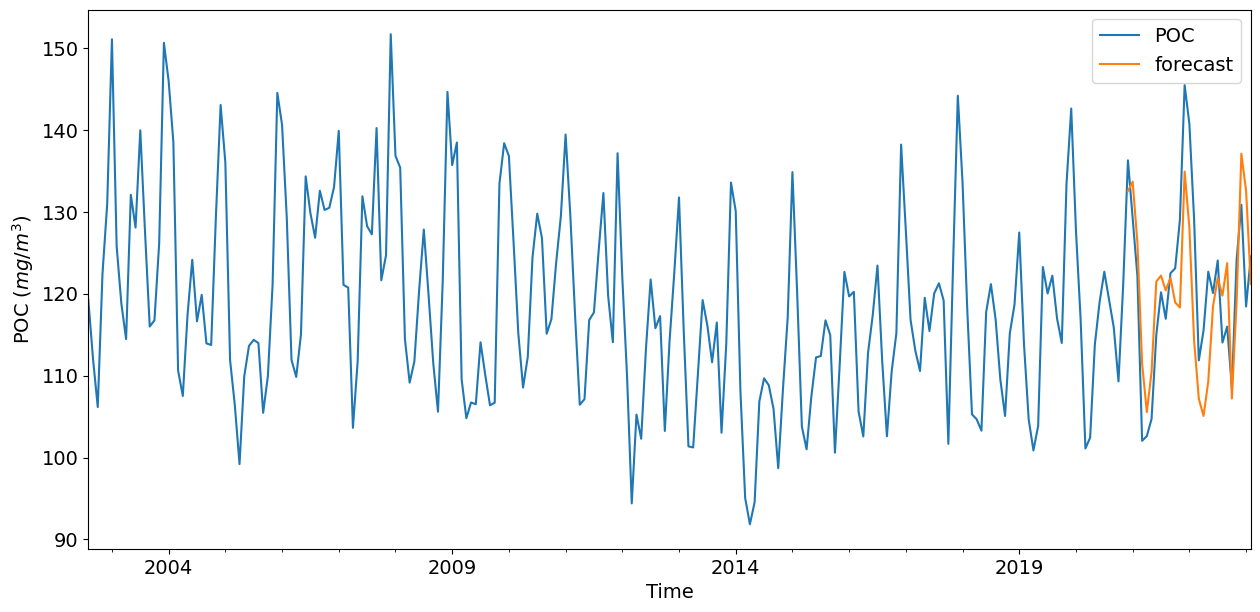

In [ ]:
# Increase font size globally
plt.rcParams.update({'font.size': 14})

# Plot POC and forecast training
X['forecast']=results.predict(start='2020-12-31', end='2023-02-28', dynamic=True, alpha=0.05,)
X[['POC','forecast']].plot(figsize=(15, 7))
plt.xlabel('Time')
plt.ylabel('POC $(mg/m^3)$')

savedir = os.path.join(main_path, 'Figure 12_validasi-monthly m60.pdf')
plt.savefig(savedir)

plt.show()

In [ ]:
X.head()

,POC,SST,CHL,SAL,NINO3,eioDMI,rolling_avg,rolling_std,forecast
Date,,,,,,,,,
2002-08-31,119.282833,29.038318,0.673731,32.88780,0.34,0.075,NaN,NaN,NaN
2002-09-30,112.031085,28.852276,0.635578,33.02058,0.51,0.007,NaN,NaN,NaN
2002-10-31,106.160381,29.513764,0.721020,32.89138,0.93,-0.186,NaN,NaN,NaN
2002-11-30,122.402259,29.854891,0.800629,32.60980,1.24,-0.083,NaN,NaN,NaN
2002-12-31,130.961725,29.995386,0.780790,32.37581,1.25,0.305,NaN,NaN,NaN


In [ ]:
from pandas.tseries.offsets import DateOffset
pred_date = pd.date_range('2023-03-01', '2030-12-01', freq='M')
pred_date

DatetimeIndex(['2023-03-31', '2023-04-30', '2023-05-31', '2023-06-30',
               '2023-07-31', '2023-08-31', '2023-09-30', '2023-10-31',
               '2023-11-30', '2023-12-31', '2024-01-31', '2024-02-29',
               '2024-03-31', '2024-04-30', '2024-05-31', '2024-06-30',
               '2024-07-31', '2024-08-31', '2024-09-30', '2024-10-31',
               '2024-11-30', '2024-12-31', '2025-01-31', '2025-02-28',
               '2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30',
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31',
               '2025-11-30', '2025-12-31', '2026-01-31', '2026-02-28',
               '2026-03-31', '2026-04-30', '2026-05-31', '2026-06-30',
               '2026-07-31', '2026-08-31', '2026-09-30', '2026-10-31',
               '2026-11-30', '2026-12-31', '2027-01-31', '2027-02-28',
               '2027-03-31', '2027-04-30', '2027-05-31', '2027-06-30',
               '2027-07-31', '2027-08-31', '2027-09-30', '2027-10-31',
      

In [ ]:
pred_date=pd.DataFrame(index=pred_date,columns=X.columns)
pred_date.head()

,POC,SST,CHL,SAL,NINO3,eioDMI,rolling_avg,rolling_std,forecast
2023-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
X=pd.concat([X,pred_date])

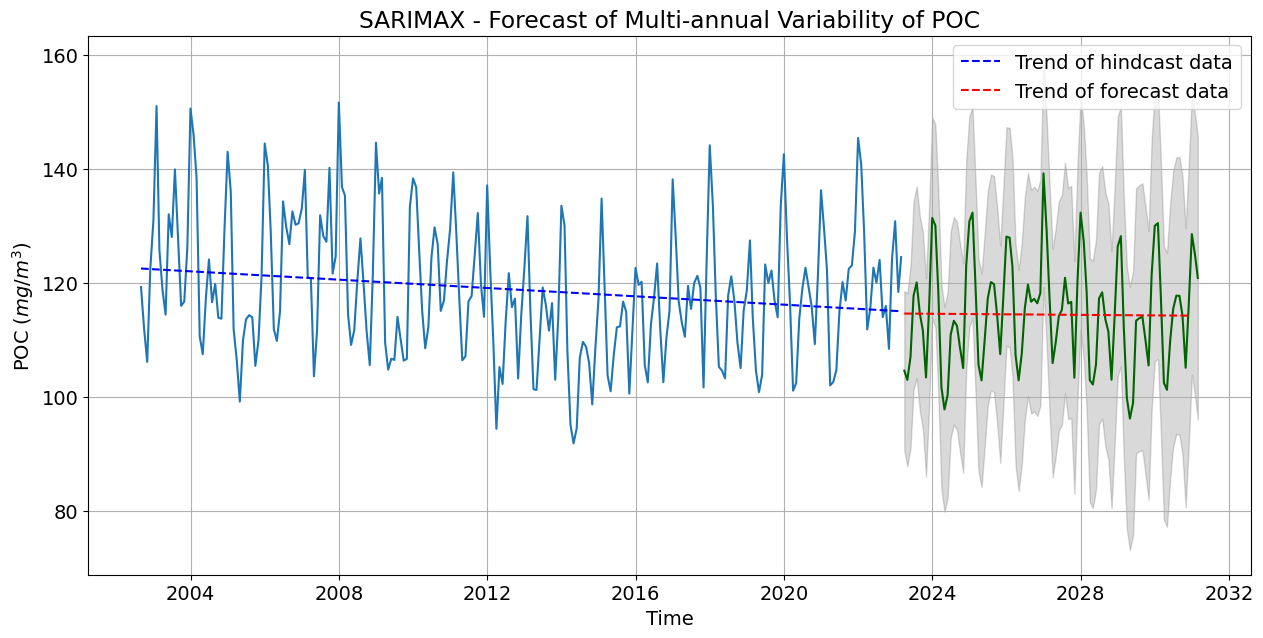

In [ ]:
# Increase font size globally
plt.rcParams.update({'font.size': 14})

# SARIMAX
def sarimax_forecast(SARIMAX_model, periods=96):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month_index":pd.date_range(df.index[-1], periods = n_periods, freq='M').month},
                    index = pd.date_range(df.index[-1]+ pd.DateOffset(months=1), periods = n_periods, freq='M'))

    fitted, confint = SARIMAX_model.predict(n_periods=n_periods,
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='M')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # Print forecasted values
    forecast_values = pd.Series(fitted, index=index_of_fc)
    print("Forecasted values:")
    print(forecast_values)

    # Save forecast values to Excel/csv
    forecast_values.to_csv('forecast_values.csv', header=['Forecast Values'])

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(df["POC"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index,
                    lower_series,
                    upper_series,
                    color='k', alpha=.15)

    from matplotlib.dates import YearLocator, DateFormatter
    from sklearn.linear_model import LinearRegression
    X['forecast'] = results.predict(start='2023-03-31', end='2030-12-31', dynamic=True)

    # trend of initial/hindcast data
    reg_data = X.POC.dropna()
    index = reg_data.index
    y = reg_data.values
    x = np.arange(len(y)).reshape(-1, 1)

    reg = LinearRegression()
    reg.fit(x, y)
    pred = reg.predict(x)

    ax = plt.subplot()
    ax.plot(index, pred, 'b--', label='Trend of hindcast data')

    # trend of forecasted data
    reg_data = X.forecast.dropna()
    index = reg_data.index
    y = reg_data.values
    x = np.arange(len(y)).reshape(-1, 1)

    reg = LinearRegression()
    reg.fit(x, y)
    pred = reg.predict(x)

    ax = plt.subplot()
    ax.plot(index, pred, 'r--', label='Trend of forecast data')
    ax.grid(['x'])
    ax.legend()

    plt.title("SARIMAX - Forecast of Multi-annual Variability of POC")
    plt.xlabel('Time')
    plt.ylabel('POC $(mg/m^3)$')
    savedir = os.path.join(main_path, 'Figure 13_final result-forecast SARIMAX.pdf')
    plt.savefig(savedir)
    plt.show()

sarimax_forecast(SARIMAX_model, periods=96)

In [ ]:
X['forecast'] = results.predict(start='2021-12-31', end='2030-12-31', dynamic=True)
X.head()

,POC,SST,CHL,SAL,NINO3,eioDMI,rolling_avg,rolling_std,forecast
2002-08-31,119.282833,29.038318,0.673731,32.88780,0.34,0.075,NaN,NaN,NaN
2002-09-30,112.031085,28.852276,0.635578,33.02058,0.51,0.007,NaN,NaN,NaN
2002-10-31,106.160381,29.513764,0.721020,32.89138,0.93,-0.186,NaN,NaN,NaN
2002-11-30,122.402259,29.854891,0.800629,32.60980,1.24,-0.083,NaN,NaN,NaN
2002-12-31,130.961725,29.995386,0.780790,32.37581,1.25,0.305,NaN,NaN,NaN


In [ ]:
print(X.tail(), end='\n\n')
X.tail()

,POC,SST,CHL,SAL,NINO3,eioDMI,rolling_avg,rolling_std,forecast
2030-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.724516
2030-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.701597
2030-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.192185
2030-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105.073890
2030-11-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.935492


In [ ]:
print(X['forecast'])

In [ ]:
display(X.to_string())

'                   POC        SST       CHL       SAL  NINO3  eioDMI  rolling_avg  rolling_std    forecast\n2002-08-31  119.282833  29.038318  0.673731  32.88780   0.34   0.075          NaN          NaN         NaN\n2002-09-30  112.031085  28.852276  0.635578  33.02058   0.51   0.007          NaN          NaN         NaN\n2002-10-31  106.160381  29.513764  0.721020  32.89138   0.93  -0.186          NaN          NaN         NaN\n2002-11-30  122.402259  29.854891  0.800629  32.60980   1.24  -0.083          NaN          NaN         NaN\n2002-12-31  130.961725  29.995386  0.780790  32.37581   1.25   0.305          NaN          NaN         NaN\n2003-01-31  151.047219  29.042313  0.966597  32.37525   0.71   0.205          NaN          NaN         NaN\n2003-02-28  125.773151  28.945690  0.783990  32.43914   0.28   0.225          NaN          NaN         NaN\n2003-03-31  118.751096  29.916755  0.739959  32.49103   0.10   0.187          NaN          NaN         NaN\n2003-04-30  114.455429  30.

In [ ]:
print(X.to_string())

In [ ]:
from statsmodels.tsa.stattools import acf

# Accuracy metrics
def forecast_accuracy(forecast, POC):
    mape = np.mean(np.abs(forecast - POC)/np.abs(POC))  # MAPE
    me = np.mean(forecast - POC)             # ME
    mae = np.mean(np.abs(forecast - POC))    # MAE
    mpe = np.mean((forecast - POC)/POC)   # MPE
    rmse = np.mean((forecast - POC)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, POC)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None],
                              POC[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None],
                              POC[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(forecast-POC)[1]                      # ACF1
    return({'mape':mape, 'me':me, 'mae': mae,
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1,
            'corr':corr, 'minmax':minmax})

model=sm.tsa.statespace.SARIMAX(X.POC,order=(1, 1, 1),seasonal_order=(2,1,0,60))
results=model.fit()
fc=results.predict(start='2020-12-31', end='2023-02-28', dynamic=True, alpha=0.05,)

test = X.POC.dropna().loc[fc.index]

forecast_accuracy(fc.values, test.values)

print('=========== Statistic result ===========\n\n')
print(forecast_accuracy(fc.values, test.values))

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)


In [ ]:
# Save forecast values to Excel/csv
X['forecast'].to_csv('forecast_values.csv', header=['Forecast Values'])